## Load Data and Libraries

In [19]:
# from google.cloud import bigquery
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, auc, 
                             classification_report, RocCurveDisplay, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, recall_score, precision_score)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df = pd.read_csv("data/cleaned_data.csv", index_col=0)
print("Data Loaded")
print(f"Shape of the data: {df.shape}")

print(f"Columns: {df.columns.tolist()}")
print(f"Data types:\n{df.dtypes}")

Data Loaded
Shape of the data: (34830, 24)
Columns: ['care_unit', 'admission_type', 'admission_location', 'language', 'marital_status', 'race', 'hospital_expire_flag', 'gender', 'age', 'rr_interval', 'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'ecg_bucket', 'temperature', 'spo2', 'glucose', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate']
Data types:
care_unit                object
admission_type           object
admission_location       object
language                 object
marital_status           object
race                     object
hospital_expire_flag      int64
gender                    int64
age                       int64
rr_interval             float64
qrs_onset               float64
qrs_end                 float64
t_end                   float64
qrs_axis                float64
t_axis                  float64
ecg_bucket               object
temperature             float64
spo2                    float64
glucose                 float64
heart_rate              float

## Exploratory Data Analysis

In [20]:
print("Class distribution:")
print(df[df['hospital_expire_flag'] == 1].shape[0], df[df['hospital_expire_flag'] == 0].shape[0])
print(f"\nMortality rate: {df['hospital_expire_flag'].mean():.2%}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

Class distribution:
4195 30635

Mortality rate: 12.04%

Missing values per column:
Series([], dtype: int64)


## Preprocessing

In [21]:
categorical_cols = [
    'care_unit', 'admission_type', 'admission_location',
    'language', 'marital_status', 'race',
    'ecg_bucket'
]

numeric_cols = [
    'age', 'rr_interval', 'qrs_onset', 
    'qrs_end', 't_end','qrs_axis', 
    't_axis', 'temperature', 'spo2', 
    'glucose', 'heart_rate', 'sbp', 
    'dbp', 'mbp', 'resp_rate'
]

# Separate features and target variable
y = df['hospital_expire_flag']
X = df[categorical_cols + numeric_cols]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")
print("Data splitted into training and testing sets\n")
print("Training columns:")
print(X_train.columns)   
print("\nFirst 5 rows of the training labels:")
print(y_train.head())

Training set shape: (27864, 22), (27864,)
Testing set shape: (6966, 22), (6966,)
Data splitted into training and testing sets

Training columns:
Index(['care_unit', 'admission_type', 'admission_location', 'language',
       'marital_status', 'race', 'ecg_bucket', 'age', 'rr_interval',
       'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'temperature',
       'spo2', 'glucose', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate'],
      dtype='object')

First 5 rows of the training labels:
18952    1
11651    0
10459    0
5871     0
26449    0
Name: hospital_expire_flag, dtype: int64


## Modeling

In [22]:
# TODO: One-hot encode categorical variables and standardize numerical features in a pipeline
# Preprocessing for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Calculate class imbalance ratio for xgboost's scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"Class ratio (neg/pos): {ratio:.1f}")

# ✅ Fix parameters we are confident about
n_estimators = 200        # fixed — tune with early stopping instead
reg_alpha    = 0          # fix at default unless overfitting
reg_lambda   = 1          # fix at default unless overfitting

# ✅ Only tune parameters with high impact (From Claude)
# High impact:  max_depth, learning_rate, scale_pos_weight
# Medium impact: subsample, colsample_bytree
# Low impact:   gamma, reg_alpha, reg_lambda (tune last if needed)

# ✅ Start simple with a small grid to find general trends, then expand if needed
param_grid = {
    'model__max_depth'        : [3, 6],          # 2 values
    'model__learning_rate'    : [0.01, 0.1],     # 2 values
    'model__scale_pos_weight' : [ratio, ratio*1.5, ratio*2], # 3 values
    'model__subsample'        : [0.7, 0.9]             # 2 values
}
# Total = 2×2×3×2 × 5 = 120 fits  ← very fast, ~2 mins

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators     = n_estimators,    # fix this — tune separately with early stopping
        random_state     = 42,
        eval_metric      = 'auc',
        verbosity        = 0
    ))
])

grid_search = GridSearchCV(
    xgb_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1,              # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best CV AUC : {grid_search.best_score_:.3f}")
print("\nBest params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {round(v, 4) if isinstance(v, float) else v}")

Class ratio (neg/pos): 7.3
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV AUC : 0.823

Best params:
  model__learning_rate: 0.1
  model__max_depth: 3
  model__scale_pos_weight: 7.3027
  model__subsample: 0.7


In [23]:
# Extract best params
best_params = grid_search.best_params_

# Preprocess data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

# Build final model with best params + early stopping
final_xgb = XGBClassifier(
    n_estimators         = 1000,   # early stopping will find optimal
    max_depth            = best_params['model__max_depth'],
    learning_rate        = best_params['model__learning_rate'],
    subsample            = best_params['model__subsample'],
    # colsample_bytree     = best_params['model__colsample_bytree'],
    scale_pos_weight     = best_params['model__scale_pos_weight'],
    random_state         = 42,
    eval_metric          = 'auc',
    verbosity            = 0,
    early_stopping_rounds = 50,  
)

final_xgb.fit(
    X_train_transformed, y_train,
    eval_set=[(X_test_transformed, y_test)],
    verbose=50
)

print(f"\nOptimal n_estimators : {final_xgb.best_iteration}")
print(f"Best AUC             : {final_xgb.best_score:.3f}")

[0]	validation_0-auc:0.71660
[50]	validation_0-auc:0.80993
[100]	validation_0-auc:0.81842
[150]	validation_0-auc:0.82237
[200]	validation_0-auc:0.82384
[250]	validation_0-auc:0.82362
[267]	validation_0-auc:0.82383

Optimal n_estimators : 217
Best AUC             : 0.824


In [24]:
final_xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators         = final_xgb.best_iteration,
        max_depth            = best_params['model__max_depth'],
        learning_rate        = best_params['model__learning_rate'],
        # subsample            = best_params['model__subsample'],
        # colsample_bytree     = best_params['model__colsample_bytree'],
        scale_pos_weight     = best_params['model__scale_pos_weight'],
        random_state         = 42,
        eval_metric          = 'auc',
        verbosity            = 0
    ))
])

final_xgb_pipe.fit(X_train, y_train)

# Evaluate
y_prob   = final_xgb_pipe.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print(f"\nFinal tuned XGBoost Test AUC: {test_auc:.3f}")

# Find best threshold
best_thresh, best_f1 = 0.5, 0
for thresh in np.arange(0.05, 0.60, 0.05):
    y_pred_t = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = round(thresh, 2)

print(f"Best threshold: {best_thresh}")
print(classification_report(y_test,
                              (y_prob >= best_thresh).astype(int),
                              target_names=['Survived', 'Died']))

# Save into existing workflow
# models_fitted['XGBoost (Tuned)']   = final_xgb_pipe
# best_thresholds['XGBoost (Tuned)'] = best_thresh


Final tuned XGBoost Test AUC: 0.820
Best threshold: 0.55
              precision    recall  f1-score   support

    Survived       0.94      0.80      0.87      6127
        Died       0.31      0.66      0.42       839

    accuracy                           0.78      6966
   macro avg       0.63      0.73      0.64      6966
weighted avg       0.87      0.78      0.81      6966



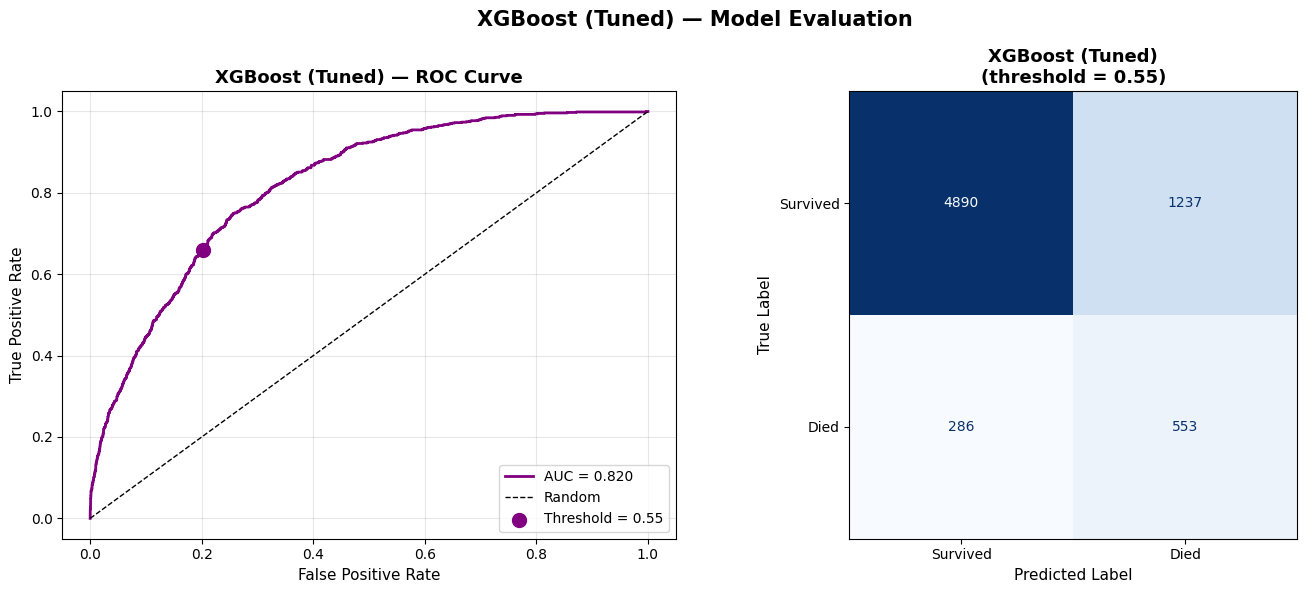

              precision    recall  f1-score   support

    Survived       0.94      0.80      0.87      6127
        Died       0.31      0.66      0.42       839

    accuracy                           0.78      6966
   macro avg       0.63      0.73      0.64      6966
weighted avg       0.87      0.78      0.81      6966

ROC AUC: 0.820


In [25]:
# ── Evaluate tuned XGBoost ──
y_prob = final_xgb_pipe.predict_proba(X_test)[:, 1]
thresh = best_thresh #best_thresholds['XGBoost (Tuned)']
y_pred = (y_prob >= thresh).astype(int)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax_roc = axes[0]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

ax_roc.plot(fpr, tpr, color='purple', lw=2,
            label=f"AUC = {roc_auc:.3f}")
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

# Mark threshold operating point
tpr_thresh = recall_score(y_test, y_pred, pos_label=1)
fpr_thresh = 1 - recall_score(y_test, y_pred, pos_label=0)
ax_roc.scatter(fpr_thresh, tpr_thresh, color='purple',
               s=100, zorder=5, label=f"Threshold = {thresh}")

ax_roc.set_xlabel('False Positive Rate', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', fontsize=11)
ax_roc.set_title('XGBoost (Tuned) — ROC Curve',
                  fontsize=13, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.grid(alpha=0.3)

# Confusion Matrix
ax_cm = axes[1]
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Survived', 'Died']
).plot(ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title(f'XGBoost (Tuned)\n(threshold = {thresh})',
                 fontsize=13, fontweight='bold')
ax_cm.set_xlabel('Predicted Label', fontsize=11)
ax_cm.set_ylabel('True Label', fontsize=11)

plt.suptitle('XGBoost (Tuned) — Model Evaluation',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sanity_outputs/xgboost_tuned_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print(classification_report(y_test, y_pred,
                              target_names=['Survived', 'Died']))
print(f"ROC AUC: {roc_auc:.3f}")